In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
BASE = '/content/drive/MyDrive/LadkiBahin/'
df = pd.read_csv(BASE + '1_beneficiaries.csv')
df_inst = pd.read_csv(BASE + '2_installment_schedule.csv')
df_dist = pd.read_csv(BASE + '3_district_summary.csv')
df_budget = pd.read_csv(BASE + '4_budget_allocation.csv')

In [ ]:
print(f"✅ Beneficiaries : {len(df):,} rows × {df.shape[1]} columns")
print(f"✅ Installments : {len(df_inst):,} rows")
print(f"✅ Districts : {len(df_dist):,} rows")
print(f"✅ Budget : {len(df_budget):,} rows")

✅ Beneficiaries : 500,000 rows × 37 columns
✅ Installments : 17 rows
✅ Districts : 36 rows
✅ Budget : 3 rows


In [ ]:
df['Application_Date'] = pd.to_datetime(df['Application_Date'], dayfirst=True)
df['First_Payment_Date'] = pd.to_datetime(df['First_Payment_Date'], dayfirst=True, errors='coerce')
df_inst['Credit_Date'] = pd.to_datetime(df_inst['Credit_Date'])

In [ ]:
cat_cols = [
    'Application_Mode', 'District', 'Division', 'Area_Type',
    'Declared_Gender', 'Marital_Status', 'Caste_Category',
    'Ration_Card_Type', 'Bank_Name', 'eKYC_Status',
    'Application_Status', 'Fraud_Type_Detected',
    'DBT_Transfer_Status', 'Grievance_Filed'
]
for col in cat_cols:
    df[col] = df[col].astype('category')

In [ ]:
print(f"Application date range: {df['Application_Date'].min().date()} → {df['Application_Date'].max().date()}")
print(f"Age range : {df['Age_at_Application'].min()} – {df['Age_at_Application'].max()}")
print(f"Income range : ₹{df['Annual_Family_Income_Rs'].min():,} – ₹{df['Annual_Family_Income_Rs'].max():,}")
print(f"\nStatus breakdown:")
print(df['Application_Status'].value_counts())

Application date range: 2024-07-01 → 2024-10-15
Age range : 21 – 65
Income range : ₹24,000 – ₹230,000

Status breakdown:
Application_Status
Active                                   374000
Suspended due to Ineligibility            55500
Suspended due to Pending Verification     42500
Pending Approval                          28000
Name: count, dtype: int64


In [ ]:
plt.rcParams.update({
    'figure.dpi'        : 150,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#FAFAF8',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'font.family'       : 'DejaVu Sans',
})

SAFFRON  = '#D85A30'
BLUE     = '#3B8BD4'
GREEN    = '#3B8040'
AMBER    = '#E8A020'
PURPLE   = '#6B5BB8'
RED      = '#C43030'
TEAL     = '#2A8A7C'
GREY     = '#888780'

STATUS_COLORS = {
    'Active'                              : GREEN,
    'Suspended due to Ineligibility'      : RED,
    'Suspended due to Pending Verification': AMBER,
    'Pending Approval'                    : GREY,
}

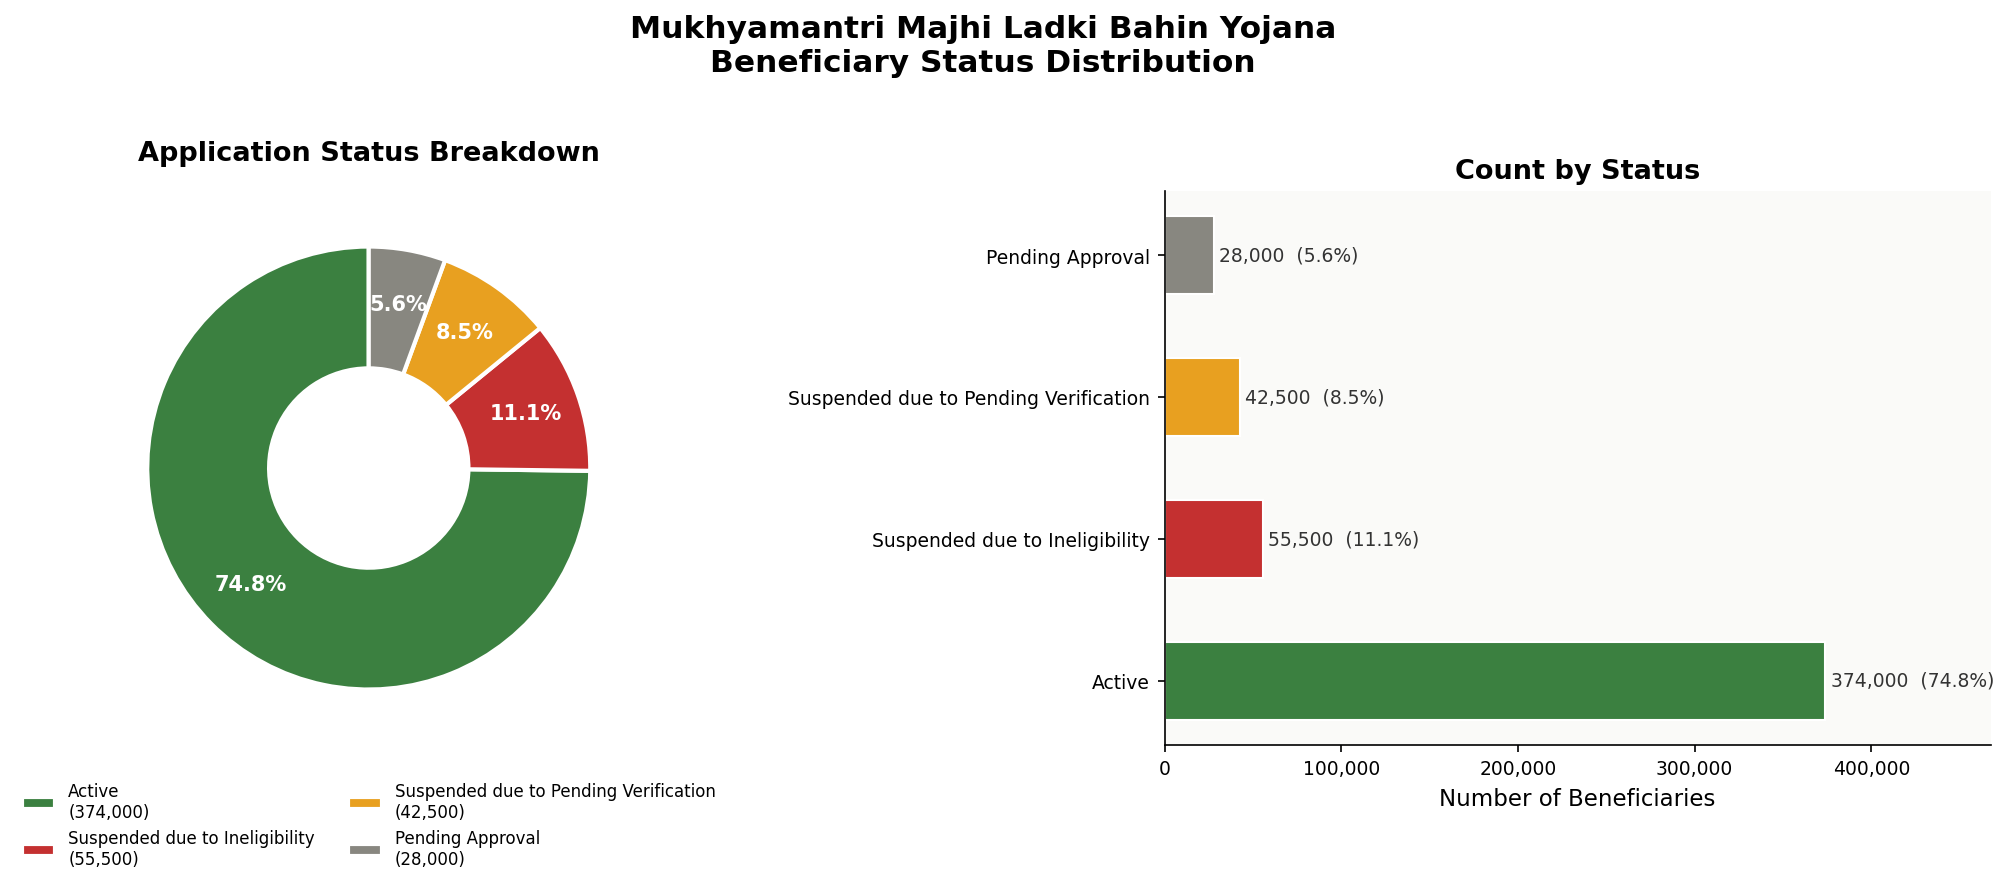

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Mukhyamantri Majhi Ladki Bahin Yojana\nBeneficiary Status Distribution',
             fontsize=15, fontweight='bold', y=1.02)

status_counts = df['Application_Status'].value_counts()
colors = [STATUS_COLORS[s] for s in status_counts.index]
wedges, texts, autotexts = axes[0].pie(
    status_counts.values,
    labels=None,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

axes[0].legend(
    wedges,
    [f"{s}\n({v:,})" for s, v in zip(status_counts.index, status_counts.values)],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.25),
    fontsize=8,
    frameon=False,
    ncol=2
)
axes[0].set_title('Application Status Breakdown', pad=15)

bars = axes[1].barh(
    status_counts.index,
    status_counts.values,
    color=colors,
    edgecolor='white',
    height=0.55
)
for bar, val in zip(bars, status_counts.values):
    axes[1].text(
        bar.get_width() + 3000,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({val/500000*100:.1f}%)',
        va='center', ha='left', fontsize=9, color='#333'
    )
axes[1].set_xlabel('Number of Beneficiaries')
axes[1].set_title('Count by Status')
axes[1].set_xlim(0, status_counts.max() * 1.25)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('chart1_status_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

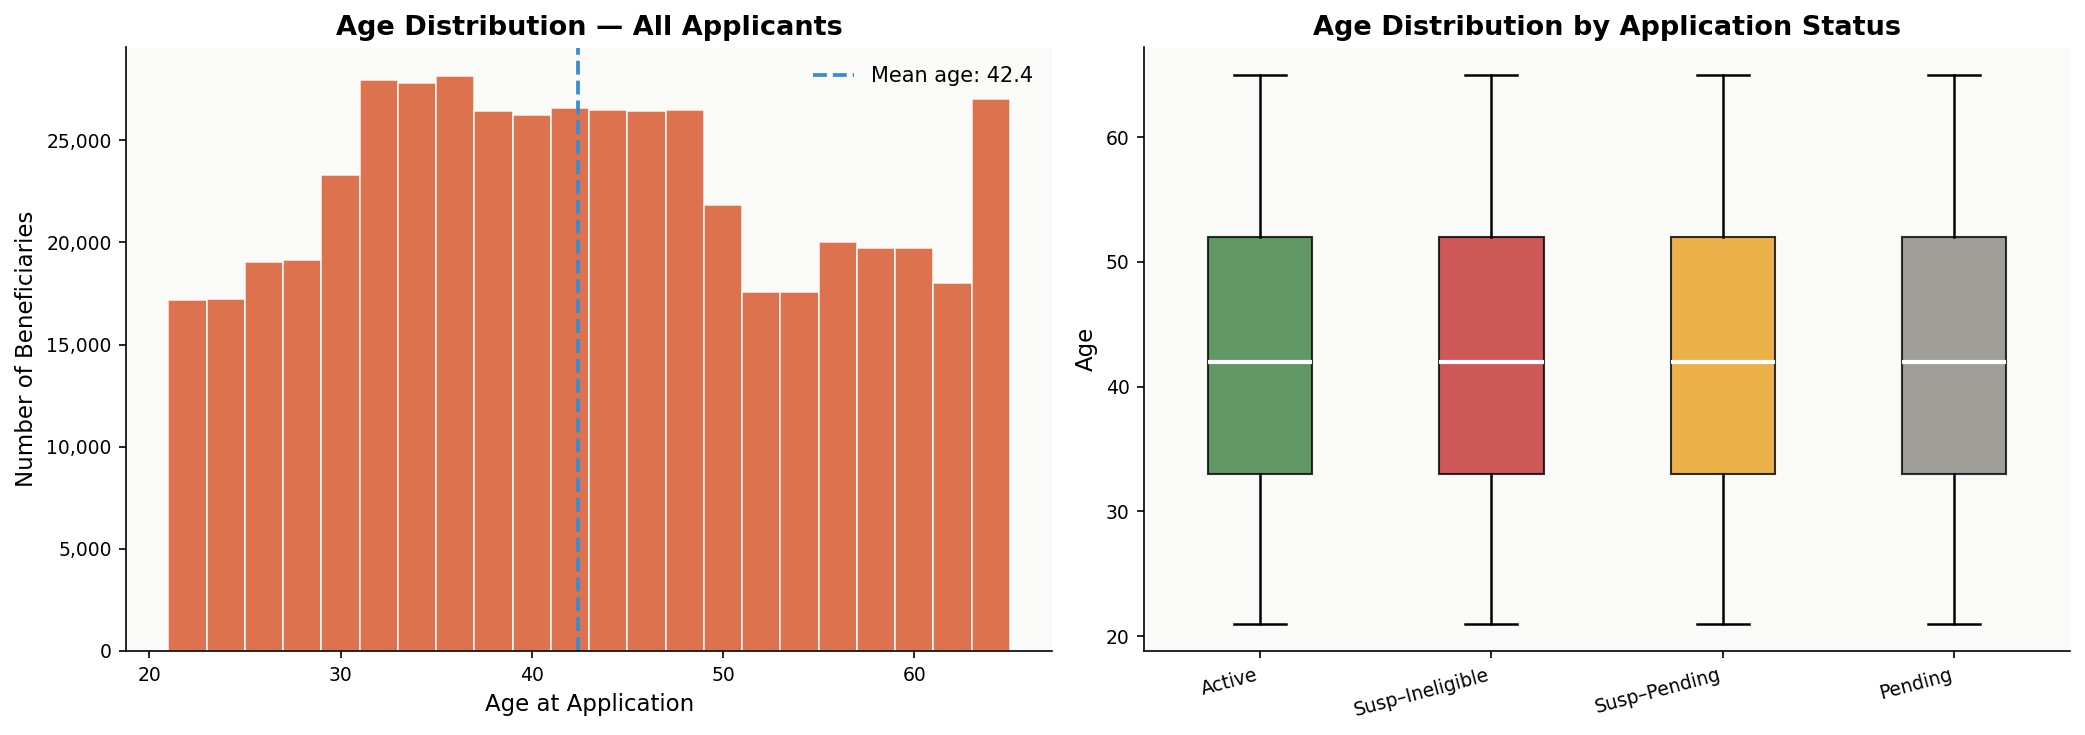

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df['Age_at_Application'],
    bins=22, color=SAFFRON, edgecolor='white',
    linewidth=0.8, alpha=0.85
)
axes[0].axvline(df['Age_at_Application'].mean(), color=BLUE,
                linestyle='--', linewidth=1.8,
                label=f"Mean age: {df['Age_at_Application'].mean():.1f}")
axes[0].set_xlabel('Age at Application')
axes[0].set_ylabel('Number of Beneficiaries')
axes[0].set_title('Age Distribution — All Applicants')
axes[0].legend(frameon=False)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

status_order = [
    'Active',
    'Suspended due to Ineligibility',
    'Suspended due to Pending Verification',
    'Pending Approval'
]
short_labels = ['Active', 'Susp–Ineligible', 'Susp–Pending', 'Pending']

data_by_status = [df[df['Application_Status'] == s]['Age_at_Application'].values
                  for s in status_order]
bp = axes[1].boxplot(
    data_by_status,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
for patch, color in zip(bp['boxes'], [STATUS_COLORS[s] for s in status_order]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

axes[1].set_xticklabels(short_labels, rotation=15, ha='right')
axes[1].set_ylabel('Age')
axes[1].set_title('Age Distribution by Application Status')

plt.tight_layout()
plt.savefig('chart2_age_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


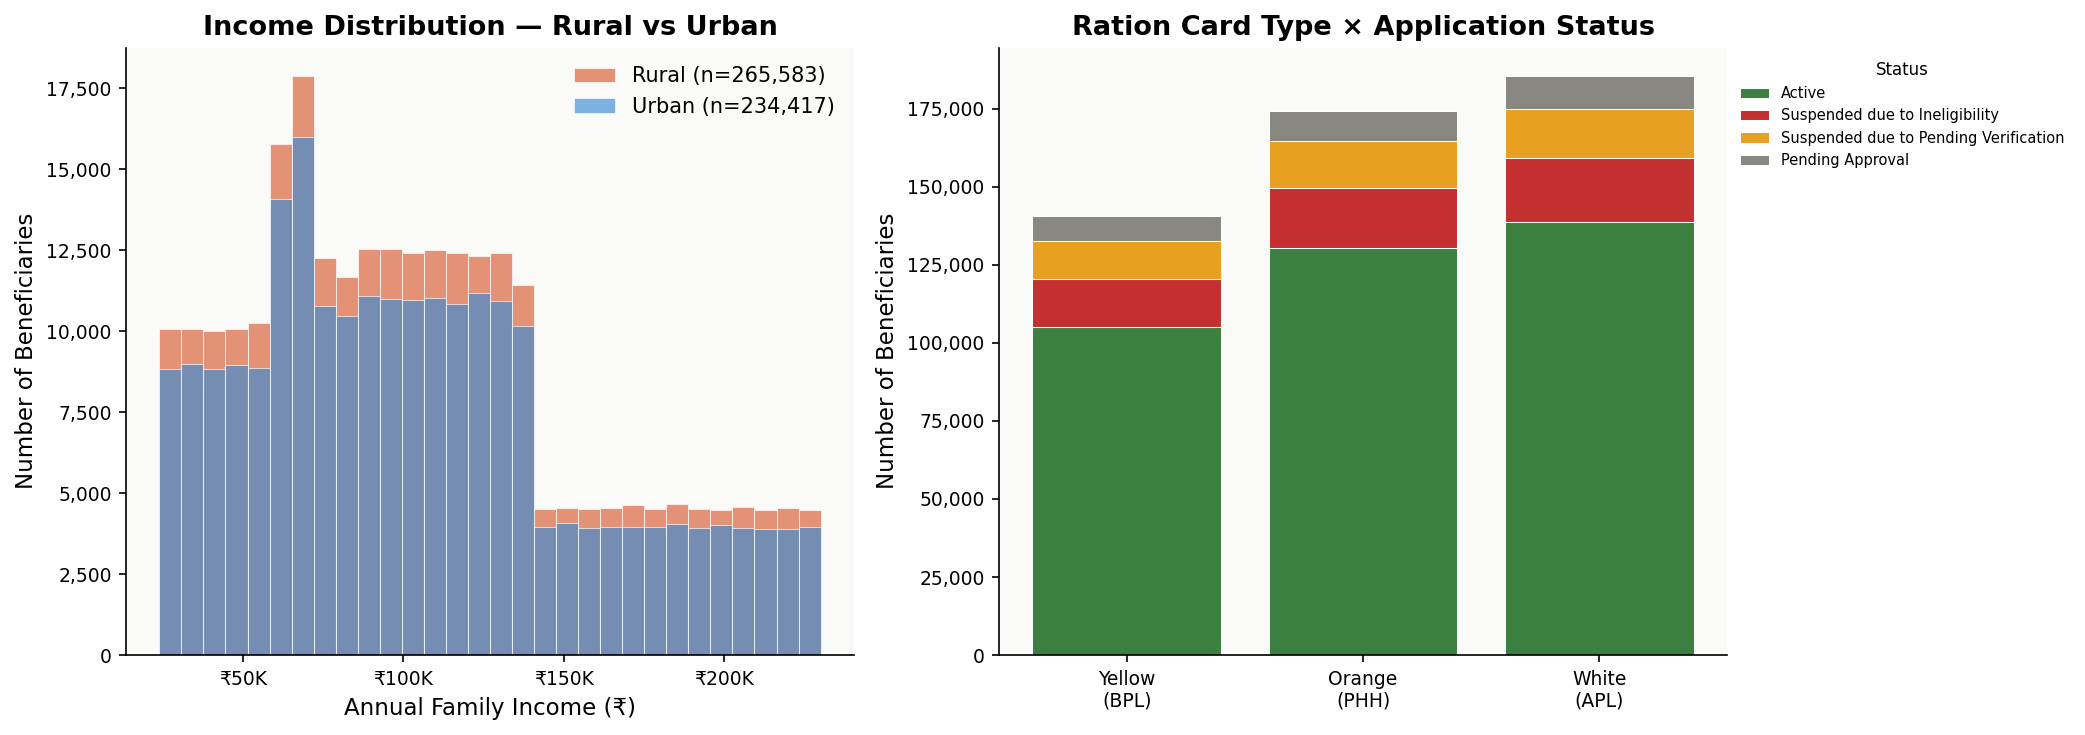

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Income histogram by area type ───────────────────────
for area, color, label in [('Rural', SAFFRON, 'Rural'), ('Urban', BLUE, 'Urban')]:
    subset = df[df['Area_Type'] == area]['Annual_Family_Income_Rs']
    axes[0].hist(subset, bins=30, color=color, alpha=0.65,
                 edgecolor='white', linewidth=0.5,
                 label=f'{label} (n={len(subset):,})')

axes[0].set_xlabel('Annual Family Income (₹)')
axes[0].set_ylabel('Number of Beneficiaries')
axes[0].set_title('Income Distribution — Rural vs Urban')
axes[0].legend(frameon=False)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'₹{int(x/1000)}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))

# ── Right: Ration card × status stacked bar ───────────────────
ration_status = df.groupby(
    ['Ration_Card_Type', 'Application_Status'], observed=True
).size().unstack(fill_value=0)

# Use exact names from your data
ration_order = [
    'Yellow (Below Poverty Line / Antyodaya)',
    'Orange (Priority Household)',
    'White (Above Poverty Line)'
]
ration_status = ration_status.reindex(ration_order)

bottom = np.zeros(len(ration_status))
for status in status_order:
    if status in ration_status.columns:
        vals = ration_status[status].values
        axes[1].bar(
            range(len(ration_status)), vals,
            bottom=bottom,
            color=STATUS_COLORS[status],
            label=status, edgecolor='white', linewidth=0.5
        )
        bottom += vals

axes[1].set_xticks(range(len(ration_status)))
axes[1].set_xticklabels(
    ['Yellow\n(BPL)', 'Orange\n(PHH)', 'White\n(APL)'],
    rotation=0
)
axes[1].set_ylabel('Number of Beneficiaries')
axes[1].set_title('Ration Card Type × Application Status')
axes[1].legend(
    title='Status', fontsize=7, title_fontsize=8,
    frameon=False, bbox_to_anchor=(1, 1), loc='upper left'
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('chart3_income_ration.png', bbox_inches='tight', dpi=150)
plt.show()

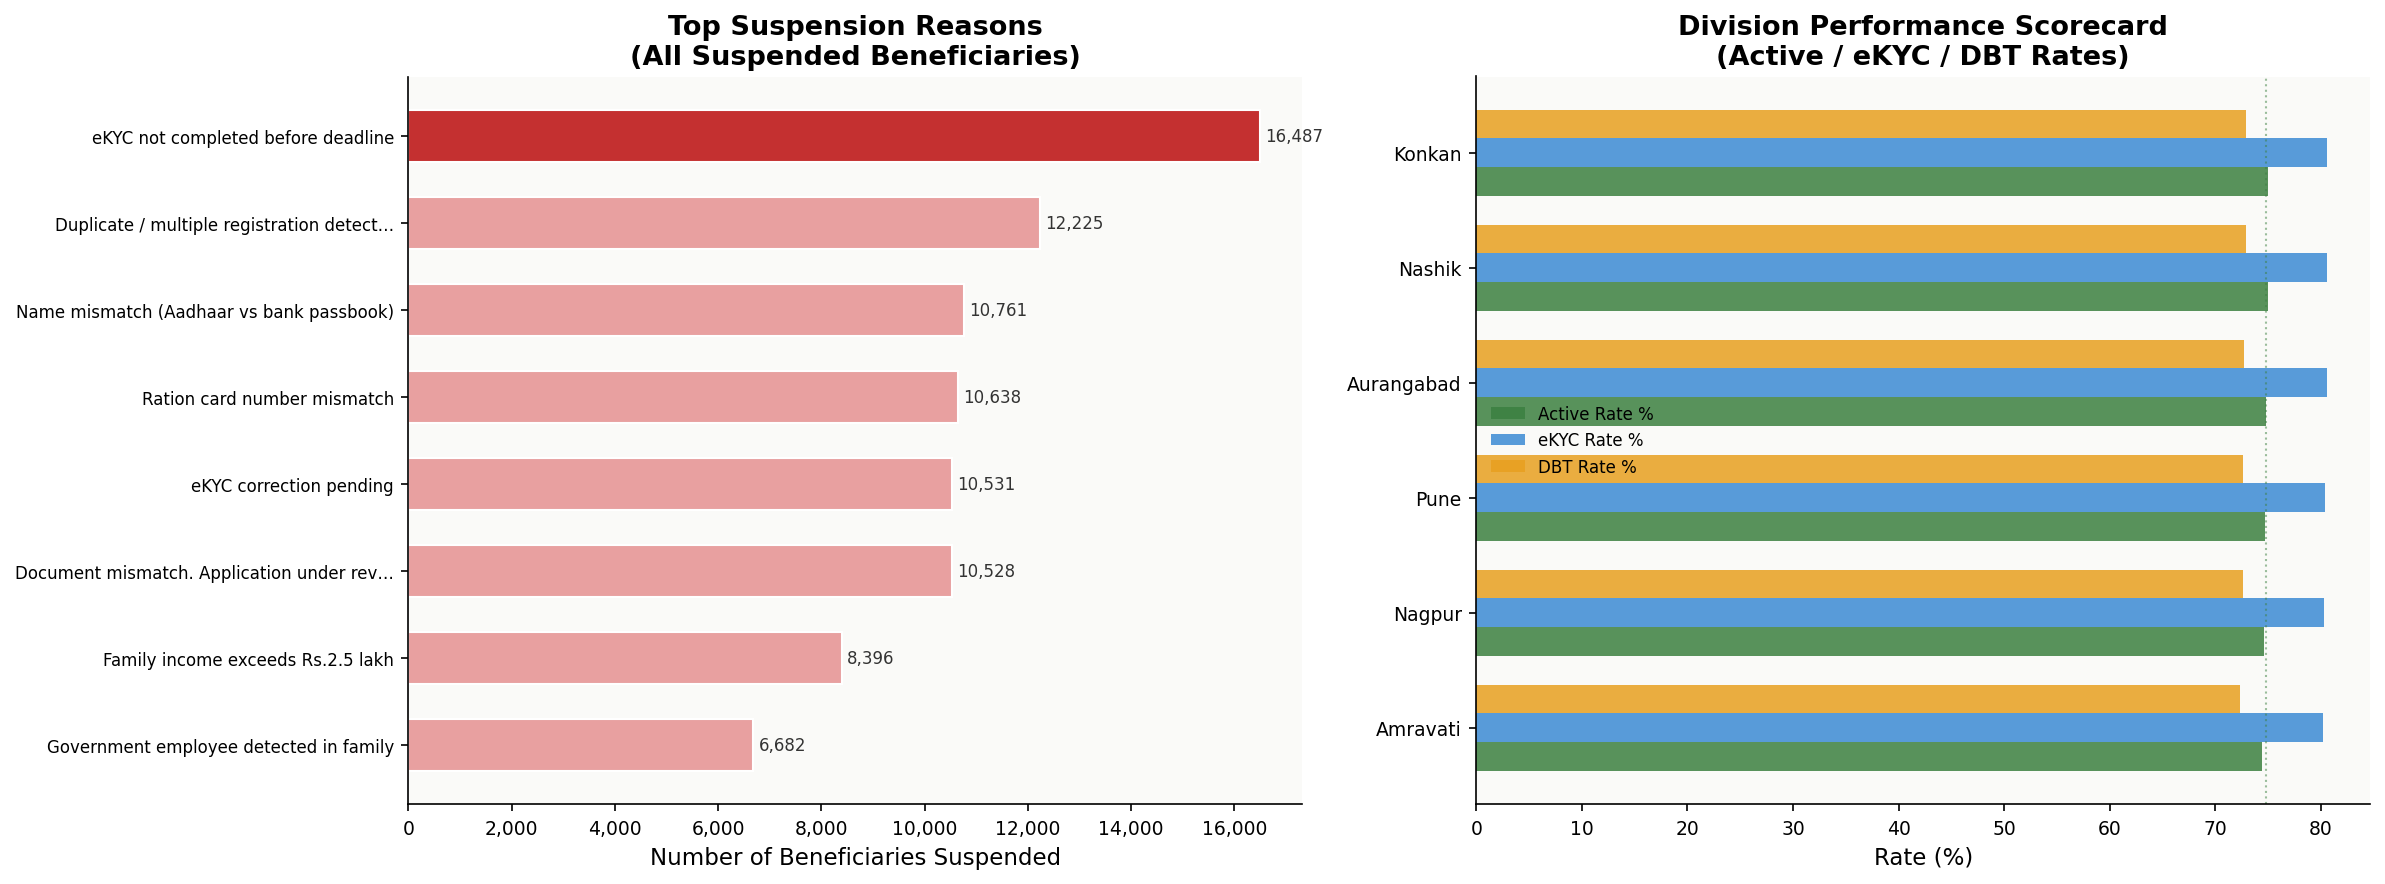

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

susp_df = df[df['Application_Status'].isin([
    'Suspended due to Ineligibility',
    'Suspended due to Pending Verification'
])].copy()

reason_counts = (
    susp_df['Suspension_Rejection_Reason']
    .value_counts()
    .head(8)
    .sort_values()
)
colors_bar = [RED if i == len(reason_counts)-1 else '#E8A0A0'
              for i in range(len(reason_counts))]
bars = axes[0].barh(reason_counts.index, reason_counts.values,
                    color=colors_bar, edgecolor='white', height=0.6)
for bar, val in zip(bars, reason_counts.values):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8, color='#333')
axes[0].set_xlabel('Number of Beneficiaries Suspended')
axes[0].set_title('Top Suspension Reasons\n(All Suspended Beneficiaries)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[0].set_yticklabels([
    label.get_text()[:40] + '…' if len(label.get_text()) > 40
    else label.get_text()
    for label in axes[0].get_yticklabels()
], fontsize=8)

div_perf = df.groupby('Division', observed=True).agg(
    Active_Rate   = ('Application_Status', lambda x: (x == 'Active').sum() / len(x) * 100),
    eKYC_Rate     = ('eKYC_Status', lambda x: (x == 'Completed').sum() / len(x) * 100),
    DBT_Rate      = ('DBT_Transfer_Status',
                     lambda x: (x == 'Credited Successfully').sum() / len(x) * 100),
).reset_index().sort_values('Active_Rate', ascending=True)

x = np.arange(len(div_perf))
w = 0.25
axes[1].barh(x - w, div_perf['Active_Rate'],  w, label='Active Rate %',  color=GREEN,  alpha=0.85)
axes[1].barh(x,     div_perf['eKYC_Rate'],    w, label='eKYC Rate %',    color=BLUE,   alpha=0.85)
axes[1].barh(x + w, div_perf['DBT_Rate'],     w, label='DBT Rate %',     color=AMBER,  alpha=0.85)
axes[1].set_yticks(x)
axes[1].set_yticklabels(div_perf['Division'])
axes[1].set_xlabel('Rate (%)')
axes[1].set_title('Division Performance Scorecard\n(Active / eKYC / DBT Rates)')
axes[1].legend(frameon=False, fontsize=8)
axes[1].axvline(74.8, color=GREEN, linestyle=':', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('chart4_5_suspension_division.png', bbox_inches='tight', dpi=150)
plt.show()


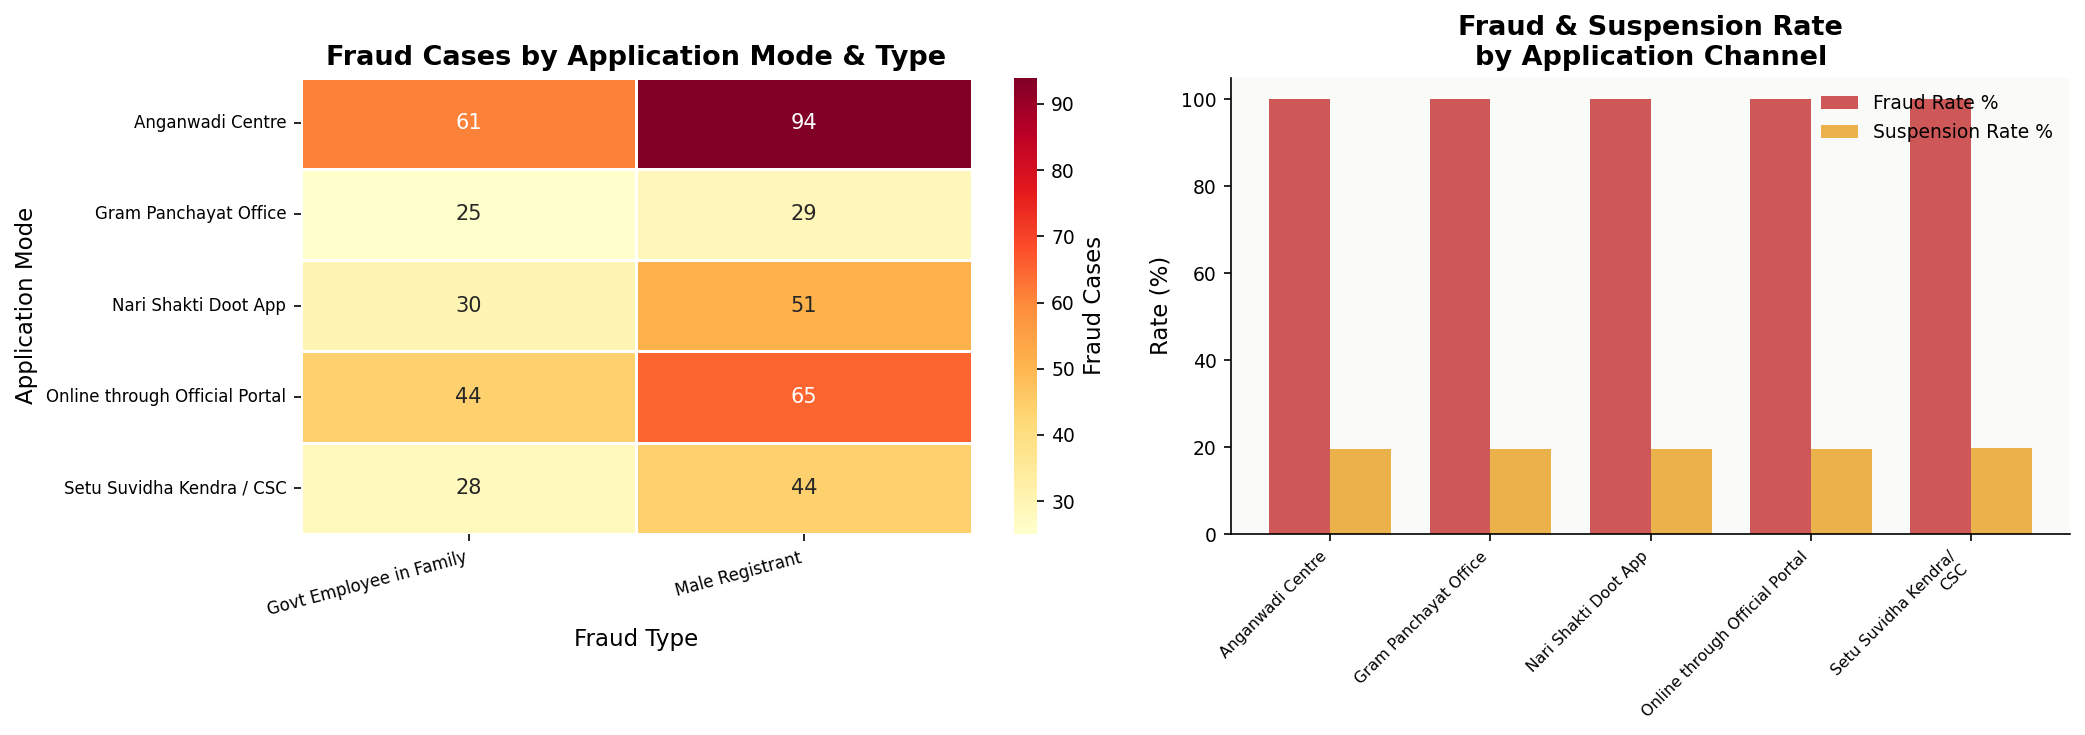

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_df = df[df['Fraud_Type_Detected'] != 'None'].copy()
fraud_pivot = pd.crosstab(
    fraud_df['Application_Mode'],
    fraud_df['Fraud_Type_Detected']
)
sns.heatmap(
    fraud_pivot, ax=axes[0],
    cmap='YlOrRd', annot=True, fmt='d',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Fraud Cases'}
)
axes[0].set_title('Fraud Cases by Application Mode & Type')
axes[0].set_xlabel('Fraud Type')
axes[0].set_ylabel('Application Mode')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right', fontsize=8)

mode_stats = df.groupby('Application_Mode', observed=True).agg(
    Total         = ('Beneficiary_ID', 'count'),
    Fraud_Cases   = ('Fraud_Type_Detected', lambda x: (x != 'None').sum()),
    Suspended     = ('Application_Status', lambda x: x.isin([
        'Suspended due to Ineligibility',
        'Suspended due to Pending Verification']).sum())
).reset_index()
mode_stats['Fraud_Rate']      = mode_stats['Fraud_Cases'] / mode_stats['Total'] * 100
mode_stats['Suspension_Rate'] = mode_stats['Suspended']   / mode_stats['Total'] * 100
mode_stats = mode_stats.sort_values('Fraud_Rate', ascending=False)

x = np.arange(len(mode_stats))
w = 0.38
b1 = axes[1].bar(x - w/2, mode_stats['Fraud_Rate'],
                 w, label='Fraud Rate %', color=RED, alpha=0.8)
b2 = axes[1].bar(x + w/2, mode_stats['Suspension_Rate'],
                 w, label='Suspension Rate %', color=AMBER, alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [m.replace(' / ', '/\n').replace(' (', '\n(')
     for m in mode_stats['Application_Mode']],
    rotation=45, ha='right', fontsize=7.5
)
axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Fraud & Suspension Rate\nby Application Channel')
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('chart6_7_fraud_mode.png', bbox_inches='tight', dpi=150)
plt.show()

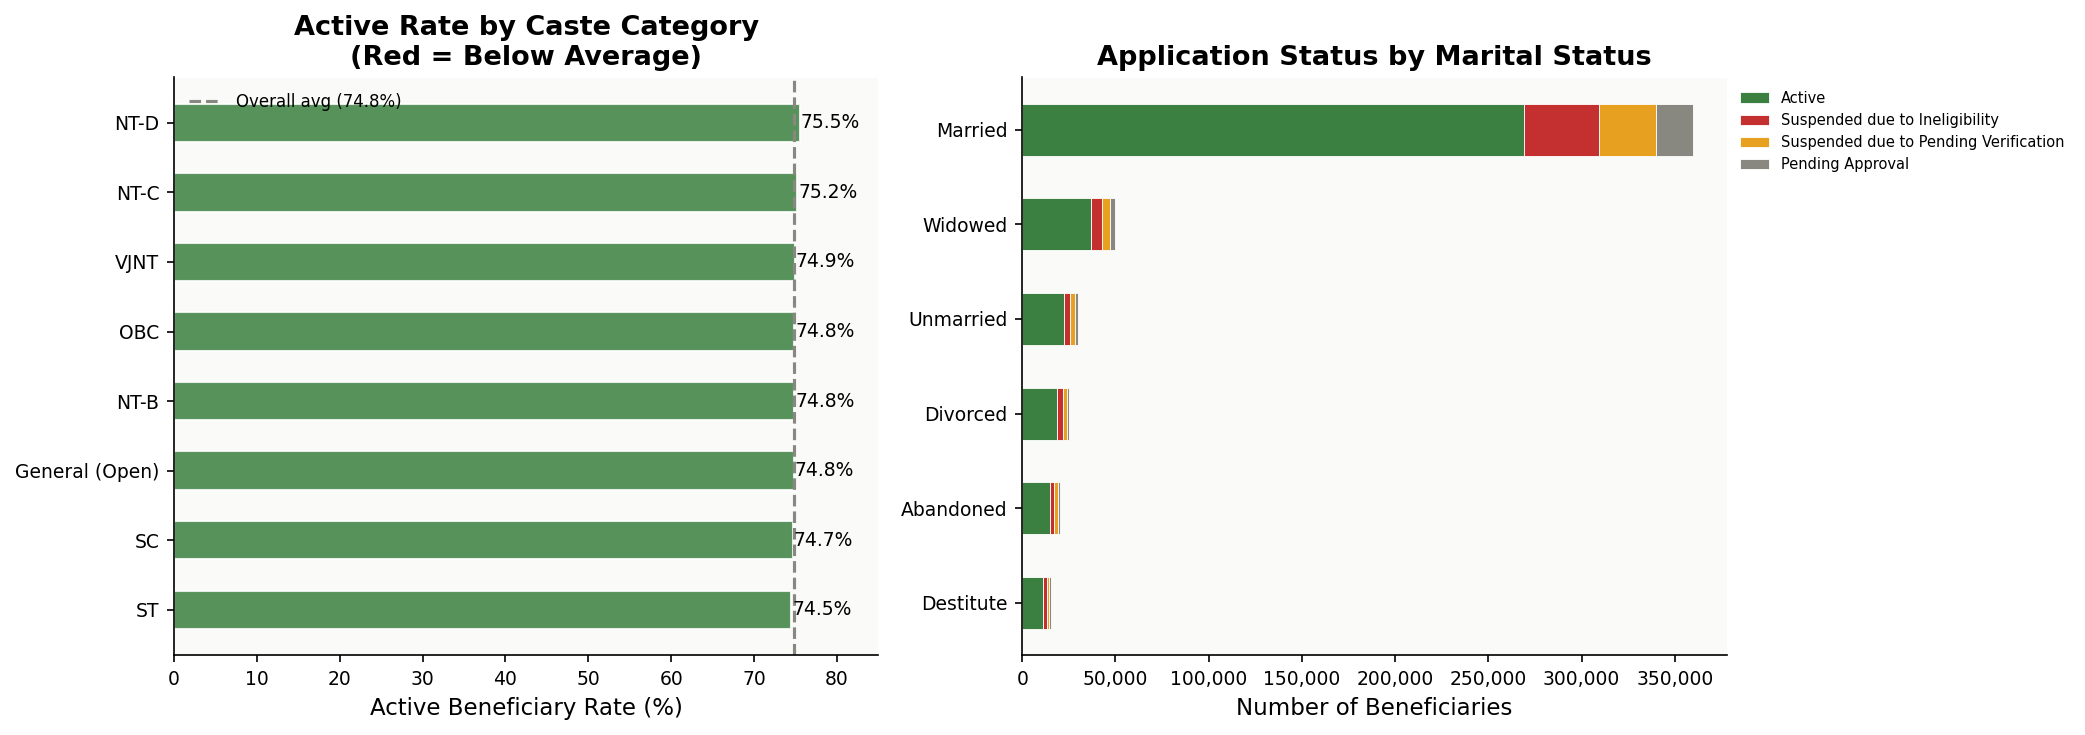

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

caste_stats = df.groupby('Caste_Category', observed=True).agg(
    Total       = ('Beneficiary_ID', 'count'),
    Active      = ('Application_Status', lambda x: (x == 'Active').sum()),
    Avg_Income  = ('Annual_Family_Income_Rs', 'mean')
).reset_index()
caste_stats['Active_Rate'] = caste_stats['Active'] / caste_stats['Total'] * 100
caste_stats = caste_stats.sort_values('Active_Rate', ascending=True)

bar_colors = [RED if r < 74 else GREEN for r in caste_stats['Active_Rate']]
bars = axes[0].barh(caste_stats['Caste_Category'], caste_stats['Active_Rate'],
                    color=bar_colors, edgecolor='white', height=0.55, alpha=0.85)
axes[0].axvline(74.8, color=GREY, linestyle='--', linewidth=1.5,
                label='Overall avg (74.8%)')
for bar, rate in zip(bars, caste_stats['Active_Rate']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{rate:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Active Beneficiary Rate (%)')
axes[0].set_title('Active Rate by Caste Category\n(Red = Below Average)')
axes[0].set_xlim(0, 85)
axes[0].legend(frameon=False, fontsize=8)

marital_status = df.groupby(
    ['Marital_Status', 'Application_Status'], observed=True
).size().unstack(fill_value=0)

marital_status = marital_status.reindex(
    marital_status.sum(axis=1).sort_values(ascending=True).index
)
bottom = np.zeros(len(marital_status))
for status in status_order:
    if status in marital_status.columns:
        vals = marital_status[status].values
        axes[1].barh(
            range(len(marital_status)), vals,
            left=bottom, color=STATUS_COLORS[status],
            label=status, edgecolor='white', linewidth=0.4, height=0.55
        )
        bottom += vals

axes[1].set_yticks(range(len(marital_status)))
axes[1].set_yticklabels(
    [label.split('(')[0].strip() for label in marital_status.index],
    fontsize=9
)
axes[1].set_xlabel('Number of Beneficiaries')
axes[1].set_title('Application Status by Marital Status')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(fontsize=7, frameon=False,
               bbox_to_anchor=(1, 1), loc='upper left')

plt.tight_layout()
plt.savefig('chart8_9_caste_marital.png', bbox_inches='tight', dpi=150)
plt.show()


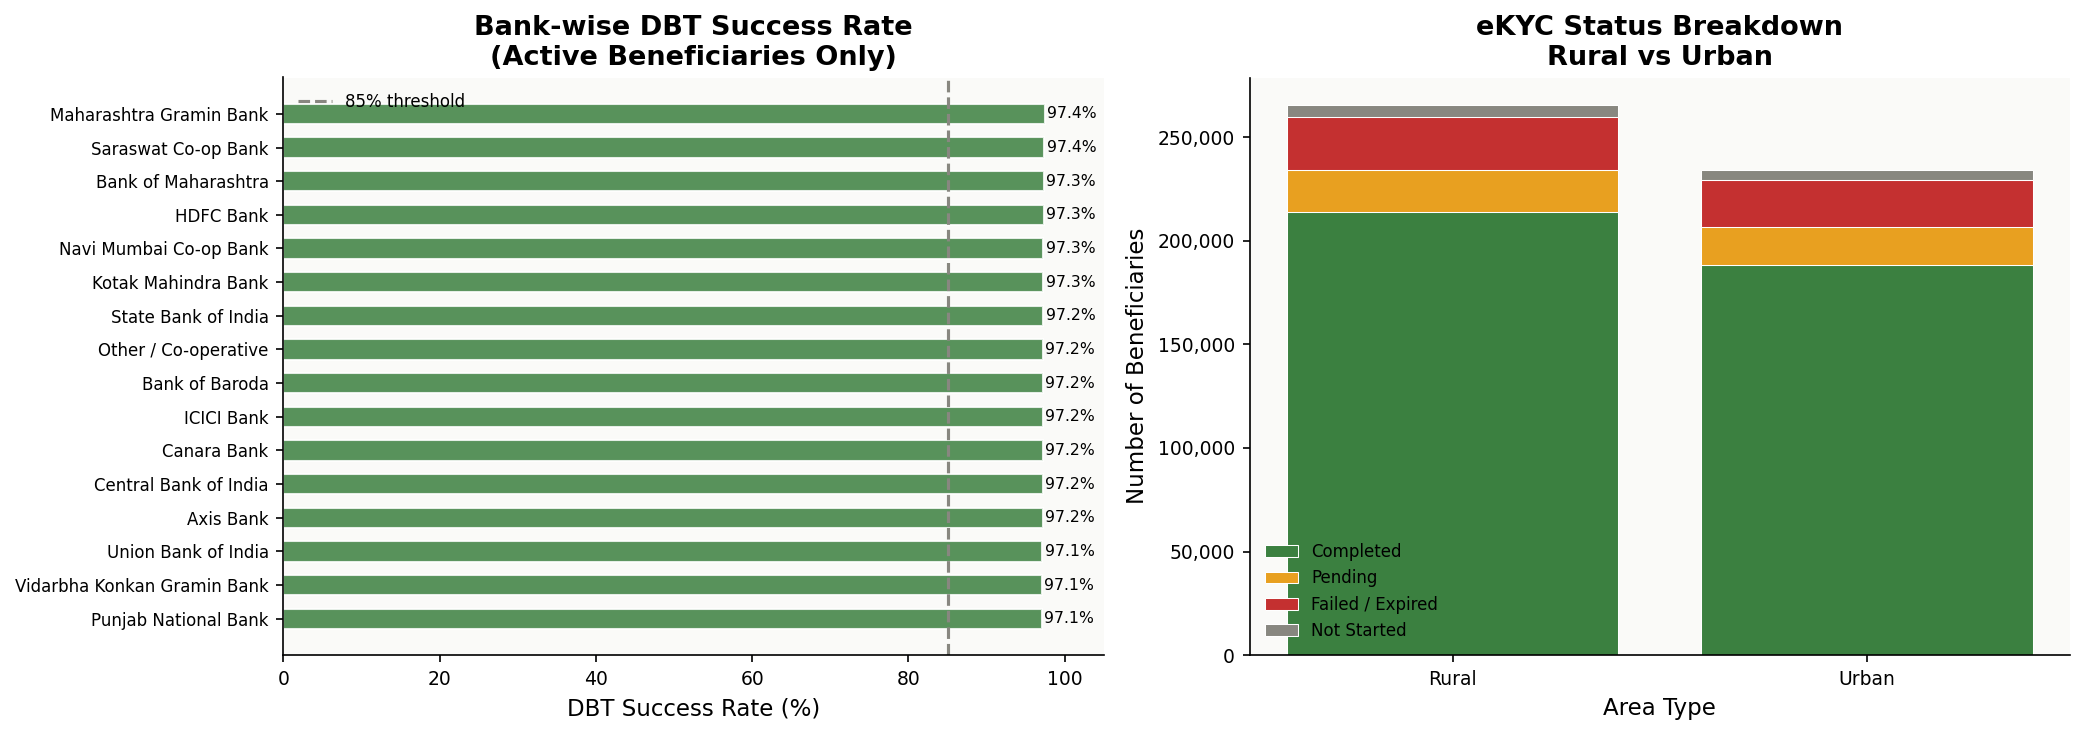

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bank_stats = df[df['Application_Status'] == 'Active'].groupby(
    'Bank_Name', observed=True
).agg(
    Total       = ('Beneficiary_ID', 'count'),
    DBT_Success = ('DBT_Transfer_Status',
                   lambda x: (x == 'Credited Successfully').sum()),
    NPCI_Gap    = ('Aadhaar_Bank_Linked_NPCI', lambda x: (x == 'No').sum())
).reset_index()
bank_stats['DBT_Rate']  = bank_stats['DBT_Success'] / bank_stats['Total'] * 100
bank_stats['NPCI_Rate'] = bank_stats['NPCI_Gap']    / bank_stats['Total'] * 100
bank_stats = bank_stats[bank_stats['Total'] > 500].sort_values('DBT_Rate')

bar_colors = [RED if r < 85 else GREEN for r in bank_stats['DBT_Rate']]
axes[0].barh(bank_stats['Bank_Name'], bank_stats['DBT_Rate'],
             color=bar_colors, edgecolor='white', height=0.6, alpha=0.85)
axes[0].axvline(85, color=GREY, linestyle='--', linewidth=1.5,
                label='85% threshold')
for i, (rate, npci) in enumerate(zip(bank_stats['DBT_Rate'], bank_stats['NPCI_Rate'])):
    axes[0].text(rate + 0.3, i, f'{rate:.1f}%', va='center', fontsize=7.5)
axes[0].set_xlabel('DBT Success Rate (%)')
axes[0].set_title('Bank-wise DBT Success Rate\n(Active Beneficiaries Only)')
axes[0].set_xlim(0, 105)
axes[0].legend(frameon=False, fontsize=8)
axes[0].tick_params(axis='y', labelsize=8)

ekyc_area = df.groupby(
    ['Area_Type', 'eKYC_Status'], observed=True
).size().unstack(fill_value=0)

ekyc_colors = {
    'Completed'      : GREEN,
    'Pending'        : AMBER,
    'Failed / Expired': RED,
    'Not Started'    : GREY
}
bottom = np.zeros(len(ekyc_area))
for status, color in ekyc_colors.items():
    if status in ekyc_area.columns:
        vals = ekyc_area[status].values
        axes[1].bar(ekyc_area.index, vals, bottom=bottom,
                    color=color, label=status,
                    edgecolor='white', linewidth=0.5)
        bottom += vals

axes[1].set_xlabel('Area Type')
axes[1].set_ylabel('Number of Beneficiaries')
axes[1].set_title('eKYC Status Breakdown\nRural vs Urban')
axes[1].legend(frameon=False, fontsize=8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('chart10_11_dbt_ekyc.png', bbox_inches='tight', dpi=150)
plt.show()


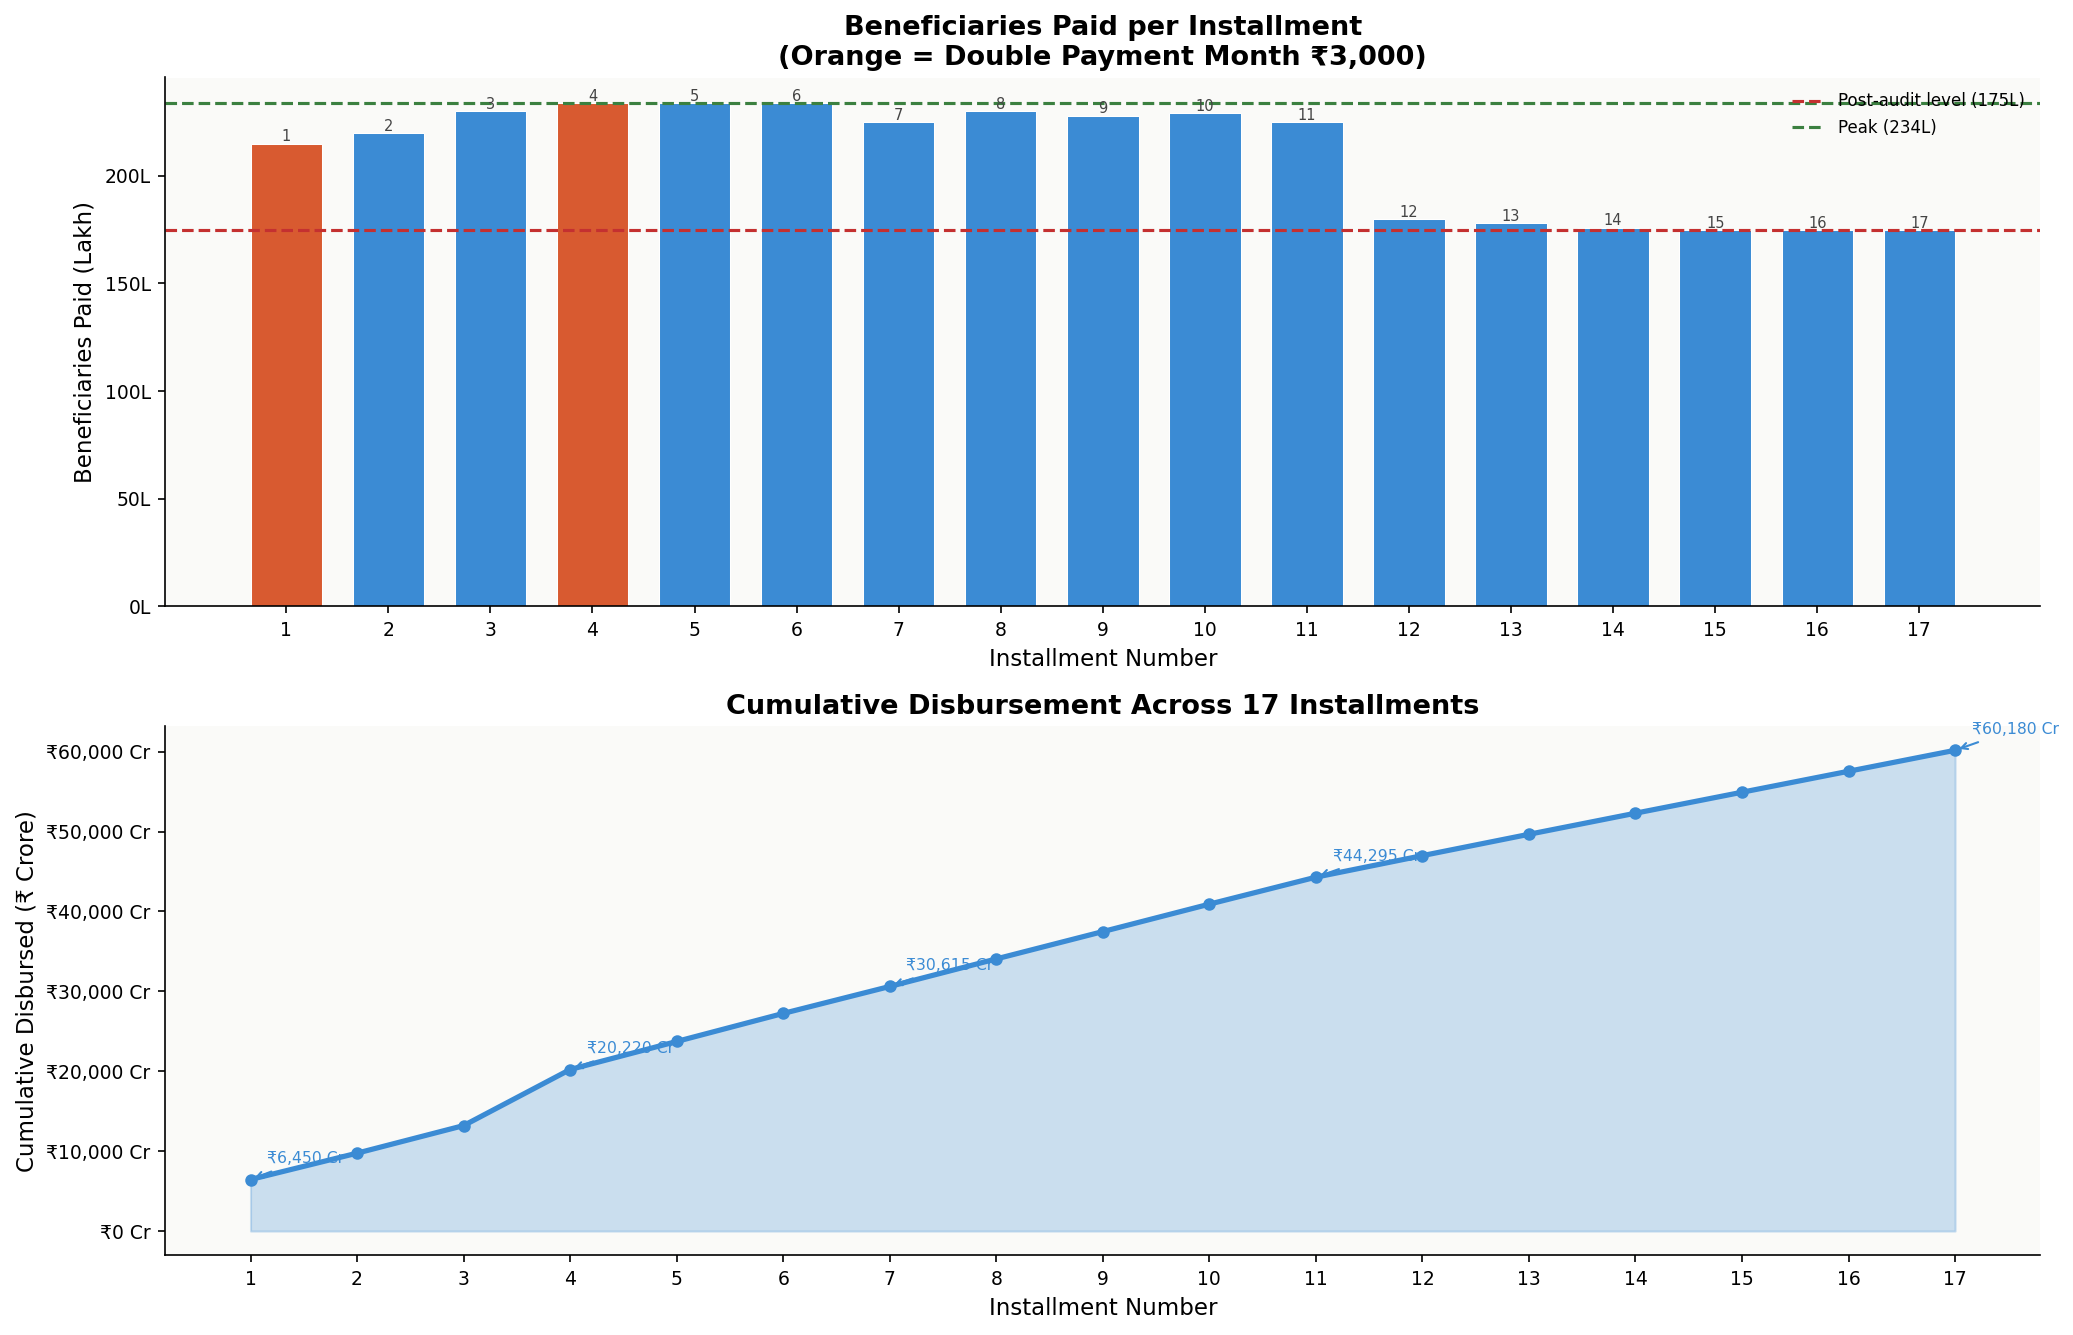

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

df_inst['Credit_Date'] = pd.to_datetime(df_inst['Credit_Date'])
colors_inst = [SAFFRON if b == 3000 else BLUE
               for b in df_inst['Amount_Per_Beneficiary_Rs']]
bars = axes[0].bar(
    df_inst['Installment_No'],
    df_inst['Beneficiaries_Paid'] / 100000,
    color=colors_inst, edgecolor='white', linewidth=0.5, width=0.7
)
axes[0].set_xlabel('Installment Number')
axes[0].set_ylabel('Beneficiaries Paid (Lakh)')
axes[0].set_title('Beneficiaries Paid per Installment\n(Orange = Double Payment Month ₹3,000)')
axes[0].set_xticks(df_inst['Installment_No'])
axes[0].axhline(175, color=RED, linestyle='--', linewidth=1.5,
                label='Post-audit level (175L)')
axes[0].axhline(234, color=GREEN, linestyle='--', linewidth=1.5,
                label='Peak (234L)')
axes[0].legend(frameon=False, fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}L'))
for bar, inst_no in zip(bars, df_inst['Installment_No']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(inst_no), ha='center', fontsize=7, color='#444')

axes[1].fill_between(
    df_inst['Installment_No'],
    df_inst['Cumulative_Disbursed_Cr_Rs'],
    alpha=0.25, color=BLUE
)
axes[1].plot(
    df_inst['Installment_No'],
    df_inst['Cumulative_Disbursed_Cr_Rs'],
    color=BLUE, linewidth=2.5, marker='o', markersize=5
)
for _, row in df_inst.iterrows():
    if row['Installment_No'] in [1, 4, 7, 11, 17]:
        axes[1].annotate(
            f"₹{row['Cumulative_Disbursed_Cr_Rs']:,.0f} Cr",
            xy=(row['Installment_No'], row['Cumulative_Disbursed_Cr_Rs']),
            xytext=(8, 8), textcoords='offset points',
            fontsize=7.5, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1)
        )
axes[1].set_xlabel('Installment Number')
axes[1].set_ylabel('Cumulative Disbursed (₹ Crore)')
axes[1].set_title('Cumulative Disbursement Across 17 Installments')
axes[1].set_xticks(df_inst['Installment_No'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f} Cr'))

plt.tight_layout()
plt.savefig('chart12_13_installments.png', bbox_inches='tight', dpi=150)
plt.show()

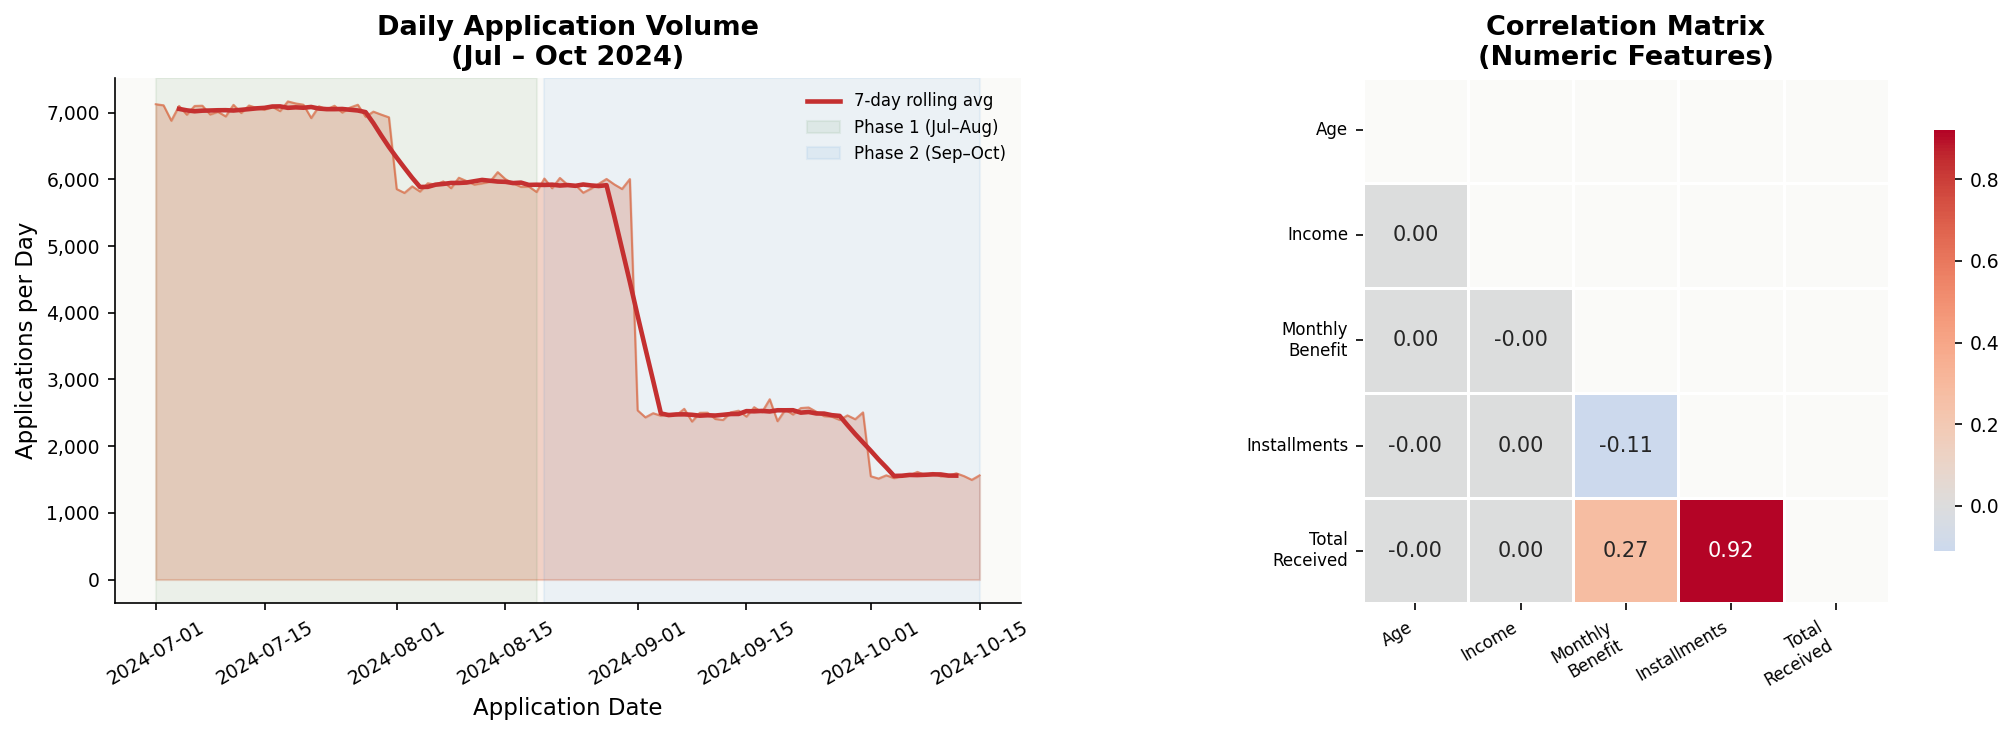

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

daily_apps = df.groupby('Application_Date').size().reset_index(name='Applications')
daily_apps['Rolling_7d'] = daily_apps['Applications'].rolling(7, center=True).mean()

axes[0].fill_between(daily_apps['Application_Date'],
                     daily_apps['Applications'],
                     alpha=0.25, color=SAFFRON)
axes[0].plot(daily_apps['Application_Date'],
             daily_apps['Applications'],
             color=SAFFRON, linewidth=1, alpha=0.6)
axes[0].plot(daily_apps['Application_Date'],
             daily_apps['Rolling_7d'],
             color=RED, linewidth=2.2, label='7-day rolling avg')

axes[0].axvspan(pd.Timestamp('2024-07-01'), pd.Timestamp('2024-08-19'),
                alpha=0.08, color=GREEN, label='Phase 1 (Jul–Aug)')
axes[0].axvspan(pd.Timestamp('2024-08-20'), pd.Timestamp('2024-10-15'),
                alpha=0.08, color=BLUE, label='Phase 2 (Sep–Oct)')
axes[0].set_xlabel('Application Date')
axes[0].set_ylabel('Applications per Day')
axes[0].set_title('Daily Application Volume\n(Jul – Oct 2024)')
axes[0].legend(frameon=False, fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=30)

numeric_cols = [
    'Age_at_Application',
    'Annual_Family_Income_Rs',
    'Monthly_Benefit_Rs',
    'Installments_Received',
    'Total_Amount_Received_Rs'
]
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    ax=axes[1],
    mask=mask,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)
short_names = ['Age', 'Income', 'Monthly\nBenefit', 'Installments', 'Total\nReceived']
axes[1].set_xticklabels(short_names, rotation=30, ha='right', fontsize=8)
axes[1].set_yticklabels(short_names, rotation=0, fontsize=8)
axes[1].set_title('Correlation Matrix\n(Numeric Features)')

plt.tight_layout()
plt.savefig('chart14_15_trends_correlation.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
print("=" * 55)
print("  PHASE 3 COMPLETE — EDA SUMMARY")
print("=" * 55)
print(f"\n  Dataset       : {len(df):,} beneficiary records")
print(f"  Date range    : Jul 1 – Oct 15, 2024")
print(f"  Charts built  : 15 across 6 analytical themes")
print(f"\n  Key findings:")
print(f"  → Active rate        : {(df['Application_Status']=='Active').mean()*100:.1f}%")
print(f"  → Suspension rate    : {df['Application_Status'].isin(['Suspended due to Ineligibility','Suspended due to Pending Verification']).mean()*100:.1f}%")
print(f"  → eKYC completed     : {(df['eKYC_Status']=='Completed').mean()*100:.1f}%")
print(f"  → DBT success rate   : {(df['DBT_Transfer_Status']=='Credited Successfully').mean()*100:.1f}%")
print(f"  → Grievances filed   : {(df['Grievance_Filed']=='Yes').sum():,}")
print(f"  → Total disbursed    : ₹{df['Total_Amount_Received_Rs'].sum()/1e7:,.0f} Cr (synthetic)")
print(f"\n  Charts saved to Colab session storage.")
print(f"  Download via Files panel (left sidebar).")
print("=" * 55)

  PHASE 3 COMPLETE — EDA SUMMARY

  Dataset       : 500,000 beneficiary records
  Date range    : Jul 1 – Oct 15, 2024
  Charts built  : 15 across 6 analytical themes

  Key findings:
  → Active rate        : 74.8%
  → Suspension rate    : 19.6%
  → eKYC completed     : 80.5%
  → DBT success rate   : 72.7%
  → Grievances filed   : 33,606
  → Total disbursed    : ₹1,094 Cr (synthetic)

  Charts saved to Colab session storage.
  Download via Files panel (left sidebar).


In [ ]:
print(df['Fraud_Type_Detected'].value_counts(dropna=False))
print()
print("Unique values:", df['Fraud_Type_Detected'].unique())

Fraud_Type_Detected
NaN                        499529
Male Registrant               283
Govt Employee in Family       188
Name: count, dtype: int64

Unique values: [NaN, 'Male Registrant', 'Govt Employee in Family']
Categories (2, object): ['Govt Employee in Family', 'Male Registrant']
